In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

### Analyze metrics

In [6]:
import pandas as pd

DIR_HERE = Path().resolve()

fpath_in = DIR_HERE / 'pop_pair_stats.csv'
df = pd.read_csv(fpath_in)
df.columns

Index(['pop_pre', 'pop_post', 'sz_pre', 'sz_post', 'r0_pre_avg', 'r0_pre_std',
       'r0_pre_cv', 'r0_post_avg', 'r0_post_std', 'r0_post_cv', 'npre_avg',
       'npre_std', 'npre_cv', 'rpre_avg', 'rpre_std', 'rpre_cv',
       'rpre_wmean_avg', 'rpre_wmean_std', 'rpre_wmean_cv', 'drpre_wmean_avg',
       'drpre_wmean_std', 'drpre_wmean_cv', 'wsum_avg', 'wsum_std', 'wsum_cv',
       'wrsum_avg', 'wrsum_std', 'wrsum_cv', 'dinput_avg', 'dinput_std',
       'dinput_cv'],
      dtype='object')

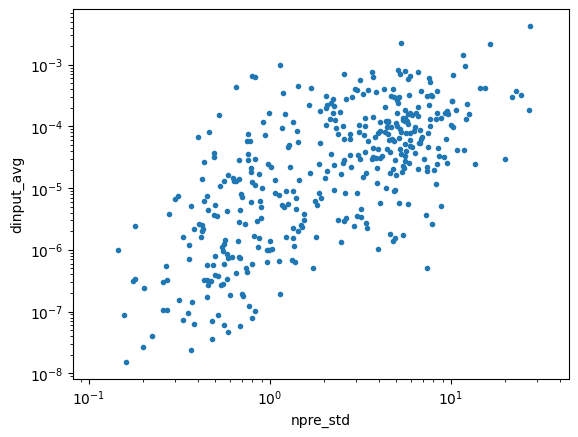

In [34]:
met_x = 'npre_std'
met_y = 'dinput_avg'

plt.figure()

plt.plot(df[met_x], df[met_y], '.')

plt.xscale('log')
plt.yscale('log')

plt.xlabel(met_x)
plt.ylabel(met_y)
plt.show()

### Visualize

In [2]:
DIR_HERE = Path().resolve()
FPATH_DATA = DIR_HERE / 'test_data/cell_inp_stats_00000_seed_1000.nc'
DIRPATH_FIGS = DIR_HERE / 'figures'

POPS_PRE = ['IT2', 'PV2', 'SOM2']
POPS_POST = ['IT2', 'IT3', 'ITP4', 'ITS4']
METRICS = {
    'n_pre': 'Number of presynaptic cells',
    'r_pre_mean': 'Mean presynaptic rate (Hz)',
    'w_sum': 'Sum of weights',
    'wr_sum': 'Weighted input',
    'r_pre_wmean': 'Weighted presynaptic rate (Hz)',
    'rate': 'Firing rate'
}
N_BINS = 40



In [3]:
def get_values(dataset, metric, pop_pre, pop_post):
    """Select finite metric values for one population pair. """
    is_pop_post = dataset['pop_post'].values == pop_post
    if 'pop_pre' in dataset[metric].coords:
        values = dataset[metric].sel(pop_pre=pop_pre).values[is_pop_post]
    else:
        values = dataset[metric].values[is_pop_post]
    return values[np.isfinite(values)]


def plot_pop_pre(dataset, pop_pre, figsize=(12, 7)):
    """Plot input distributions from one population. """
    fig, axes = plt.subplots(2, 3, figsize=figsize, constrained_layout=True)
    axes = axes.ravel()

    # Plot post populations against common bins for a fair comparison
    for ax, (metric, label) in zip(axes, METRICS.items()):
        values_by_pop = [
            get_values(dataset, metric, pop_pre, pop_post)
            for pop_post in POPS_POST
        ]
        bins = np.histogram_bin_edges(np.concatenate(values_by_pop), bins=N_BINS)

        for pop_post, values in zip(POPS_POST, values_by_pop):
            ax.hist(
                values,
                bins=bins,
                density=True,
                histtype='step',
                linewidth=1.5,
                label=f'{pop_post} (n={len(values)})',
            )

        ax.set_xlabel(label)
        ax.set_ylabel('Density')

    axes[0].legend(frameon=False, fontsize=8)
    #axes[-1].set_visible(False)
    fig.suptitle(f'Inputs from {pop_pre}')
    #fig.savefig(fpath_out, dpi=150)


def plot_pop_post(dataset, pop_post, pops_pre, figsize=(12, 7), nbins=N_BINS):
    """Plot input distributions from one population. """
    fig, axes = plt.subplots(2, 3, figsize=figsize, constrained_layout=True)
    axes = axes.ravel()

    # Plot post populations against common bins for a fair comparison
    for ax, (metric, label) in zip(axes, METRICS.items()):
        values_by_pop = [
            get_values(dataset, metric, pop_pre, pop_post)
            for pop_pre in pops_pre
        ]
        bins = np.histogram_bin_edges(np.concatenate(values_by_pop), bins=nbins)

        for pop_pre, values in zip(pops_pre, values_by_pop):
            ax.hist(
                values,
                bins=bins,
                density=True,
                histtype='step',
                linewidth=1.5,
                label=f'{pop_pre} (n={len(values)})',
            )

        #ax.set_xlabel(label)
        ax.set_title(label)
        ax.set_ylabel('Density')

    axes[0].legend(frameon=False, fontsize=8)
    #axes[-1].set_visible(False)
    fig.suptitle(f'Inputs to {pop_post}')
    #fig.savefig(fpath_out, dpi=150)

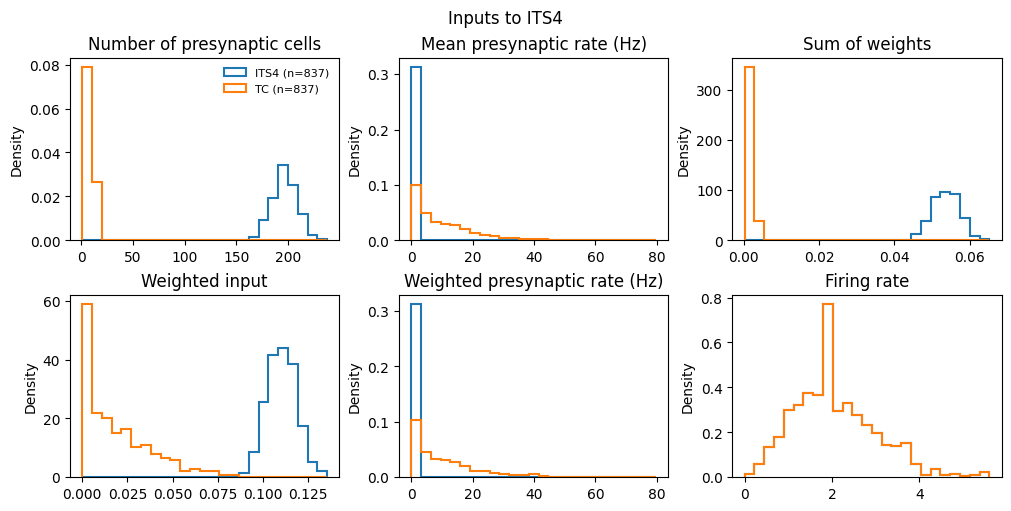

In [4]:
with xr.open_dataset(FPATH_DATA) as ds:
    ds.load()

pops_pre = ['ITS4', 'TC']
pops_post = ['ITS4']

for pop_post in pops_post:
    plot_pop_post(ds, pop_post, pops_pre=pops_pre, figsize=(10, 5), nbins=25)

In [5]:
(
    get_values(ds, 'rate', 'TC', 'ITS4')[:10],
    get_values(ds, 'rate', 'ITS4', 'TC')[:10]
)

(array([2.4, 3. , 2. , 1.8, 1.6, 2.2, 2. , 3.8, 1.4, 2.2]),
 array([ 47. ,   0. ,  14.6,   0. ,   0. ,   0.2, 130.8,  10. ,   0. ,
         22.2]))

In [6]:
ds

<xarray.Dataset> Size: 20MB
Dimensions:      (gid: 12908, pop_pre: 43)
Coordinates:
    pop_post     (gid) object 103kB 'IT2' 'IT2' 'IT2' ... 'IREM' 'IREM' 'IREM'
  * gid          (gid) int32 52kB 0 1 2 3 4 5 ... 12903 12904 12905 12906 12907
  * pop_pre      (pop_pre) object 344B 'IT2' 'IT3' 'ITP4' ... 'TCM' 'TIM' 'IREM'
Data variables:
    n_pre        (gid, pop_pre) int32 2MB 58 847 131 235 9 8 ... 8 0 13 62 0 20
    r_pre_mean   (gid, pop_pre) float64 4MB 1.272 1.98 1.835 ... 3.471 nan 11.83
    w_sum        (gid, pop_pre) float64 4MB 0.003082 0.04498 ... 0.0 0.004721
    wr_sum       (gid, pop_pre) float64 4MB 0.003934 0.08906 ... 0.0 0.05585
    r_pre_wmean  (gid, pop_pre) float64 4MB 1.277 1.98 1.835 ... 3.471 nan 11.83
    rate         (gid) float64 103kB 0.6 0.8 5.4 0.2 0.0 ... 0.6 0.0 15.4 4.8
    cv           (gid) float64 103kB 0.647 0.7643 0.615 nan ... nan 3.258 2.073
Attributes:
    t_start_s:                       15.0
    t_stop_s:                        20.0
    nspikes_min:                     3
    include_frz:                     0
    weight_semantics:                instantiated nominal conn['weight']; syn...
    dynamic_modulation:              ignored
    receptor_ratio_tolerance:        1e-08
    receptor_ratio_validation_json:  {"status": "passed", "population_pairs_c...
    seed_main:                       1000
    runtime_params_json:             {"time": {"duration": 20000.0, "t0_calc"...

In [7]:
METRICS

{'n_pre': 'Number of presynaptic cells',
 'r_pre_mean': 'Mean presynaptic rate (Hz)',
 'w_sum': 'Sum of weights',
 'wr_sum': 'Weighted input',
 'r_pre_wmean': 'Weighted presynaptic rate (Hz)',
 'rate': 'Firing rate'}

In [8]:
#ds.sel(ds['pop_post'] == 'TC')
ds.where(ds['pop_post'] == 'TC', drop=True).sizes['gid']

116

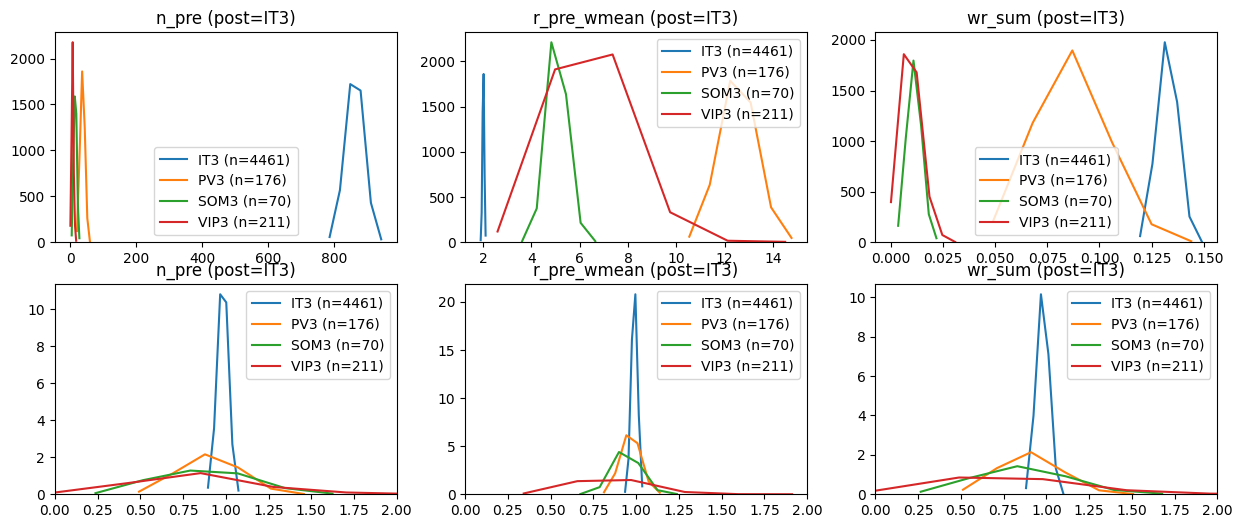

In [9]:
import warnings
warnings.filterwarnings("ignore")

nbins = 6

#pops_pre = ['ITS4', 'IT2', 'IT3', 'IT6', 'TC']
#pop_post = 'ITP4'

pops_pre = ['IT3', 'PV3', 'SOM3', 'VIP3']
pop_post = 'IT3'

mets = ['n_pre', 'r_pre_wmean', 'wr_sum']

#plt.figure()
plt.figure(figsize=(5 * len(mets), 6))

plt_num = 1
for norm in [0, 1]:
    for m, met in enumerate(mets):
        plt.subplot(2, len(mets), plt_num)
        plt_num += 1

        for n, pop_pre in enumerate(pops_pre):
            sz_pre = ds.where(ds['pop_post'] == pop_pre, drop=True).sizes['gid']

            x = get_values(ds, met, pop_pre, pop_post)
            
            if norm:
                xm = np.nanmean(x)
                #x = (x - xm) / xm
                x = x / xm

            try:
                h, b = np.histogram(x, density=norm, bins=nbins)
            except:
                h, b = [], []
            plt.plot(b[:-1], h, linewidth=1.5, label=f'{pop_pre} (n={sz_pre})')
            #plt.title(f'{pop_pre}->{pop_post}')

        plt.title(f'{met} (post={pop_post})')
        plt.legend()
        if norm:
            plt.xlim(0, 2)
        plt.ylim(0, None)

plt.show()

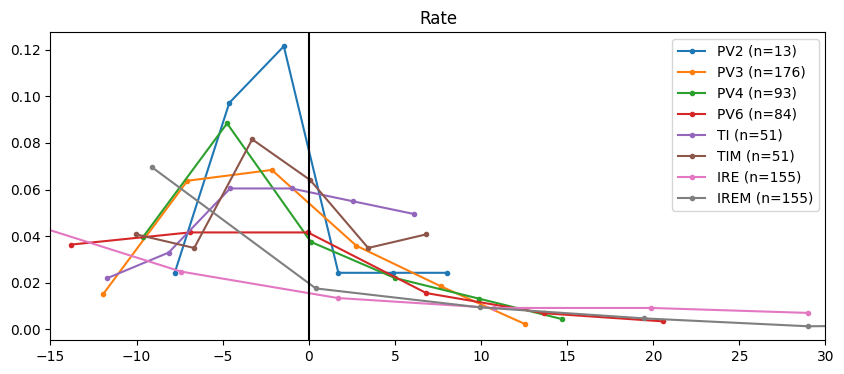

In [10]:
nbins = 6

pops = ['PV2', 'PV3', 'PV4', 'PV6', 'TI', 'TIM', 'IRE', 'IREM']

plt.figure(figsize=(10, 4))

for pop in pops:
    r = get_values(ds, 'rate', None, pop)
    sz = ds.where(ds['pop_post'] == pop, drop=True).sizes['gid']

    r -= np.mean(r)
            
    h, b = np.histogram(r, density=1, bins=nbins)
    plt.plot(b[:-1], h, '.-', linewidth=1.5, label=f'{pop} (n={sz})')

plt.axvline(0, color='k')

plt.xlim(-15, 30)
plt.title(f'Rate')
plt.legend()
plt.show()

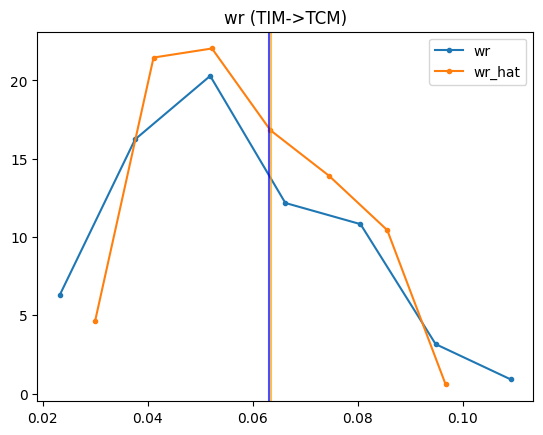

In [47]:
pop_pre = 'TIM'
pop_post = 'TCM'

mets = ['n_pre', 'r_pre_wmean', 'wr_sum']

# Size and avg rate of pre population
sz_pre = ds.where(ds['pop_post'] == pop_pre, drop=True).sizes['gid']
r_avg = np.mean(get_values(ds, 'rate', None, pop_pre))

# Metrics for every post cell, avg/sum over its pre cells
w = get_values(ds, 'w_sum', pop_pre, pop_post)
wr = get_values(ds, 'wr_sum', pop_pre, pop_post)

# Surrogate estimate of wr, with all pre rates replaced by r_avg
wr_hat = w * r_avg

xvis_all = {'wr': wr, 'wr_hat': wr_hat}

for name, xvis in xvis_all.items():
    h, b = np.histogram(xvis, density=1, bins=7)
    plt.plot(b[:-1], h, '.-', linewidth=1.5, label=name)

plt.axvline(np.nanmean(wr_hat), color='orange', alpha=0.7)
plt.axvline(np.nanmean(wr), color='blue', alpha=0.7)

#plt.xlim(-15, 30)
plt.title(f'wr ({pop_pre}->{pop_post})')
plt.legend()
plt.show()


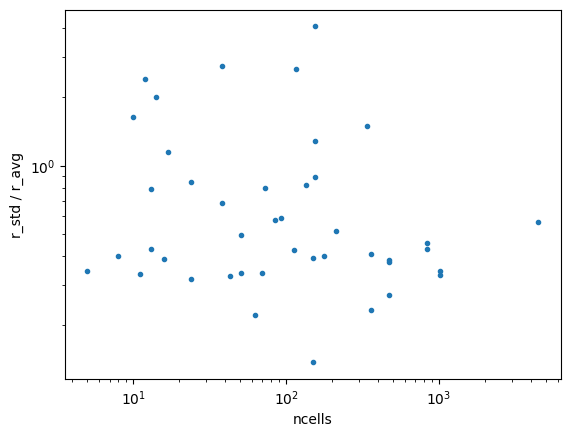

In [58]:
import pandas as pd

df = pd.read_csv('pop_stats.csv')

#plt.plot(df['ncells'], df['r_std'], '.')
plt.plot(df['ncells'], df['r_std'] / df['r_avg'], '.')
plt.xlabel('ncells')
#plt.ylabel('r_std')
plt.ylabel('r_std / r_avg')
#plt.xlim(-100, 1000)
#plt.ylim(-100, 1000)
plt.xscale('log')
plt.yscale('log')
plt.show()